# Laboratory 2: RF Propagation Modeling — Free-Space Path Loss

Martin Demel

Department of Science, Technology, Engineering & Math, Houston Community College

6263-ITAI-4370-AI 5/6G Comm & ORAN Net-S10-14071

Tawanda Chiyangwa
June 15th, 2026.


In this lab I model how a radio signal weakens as it travels, using the **Free-Space Path Loss (FSPL)** equation. FSPL is the loss between two ideal antennas with a clear path and nothing in the way, so it is the best case for a wireless link. In Part 1 I run the program from the lab brief at 2.4 GHz, and in Part 2 I compare several frequency bands to see how the choice of band affects coverage.

## Part 1: Free-Space Path Loss vs distance

Free-space path loss grows with both distance and frequency. With distance in km and frequency in MHz, the formula is **FSPL(dB) = 20·log10(d) + 20·log10(f) + 32.44**, where the constant 32.44 folds in the speed of light and the unit conversion (International Telecommunication Union [ITU], 2024). The cell below is the program from the lab brief, which plots FSPL against distance for a 2.4 GHz Wi-Fi signal.

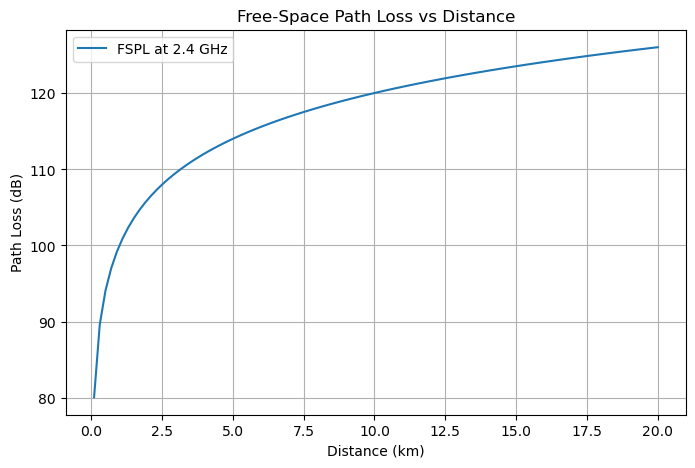

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
frequency = 2400  # MHz (2.4 GHz WiFi)
distances = np.linspace(0.1, 20, 100)  # km

# FSPL calculation
fspl = 20*np.log10(distances) + 20*np.log10(frequency) + 32.44

# Plot
plt.figure(figsize=(8,5))
plt.plot(distances, fspl, label="FSPL at 2.4 GHz")
plt.xlabel("Distance (km)")
plt.ylabel("Path Loss (dB)")
plt.title("Free-Space Path Loss vs Distance")
plt.grid(True)
plt.legend()
plt.show()

The loss rises steeply at first and then more slowly, because it is logarithmic in distance. At 2.4 GHz it is about 100 dB at 1 km and 126 dB at 20 km, which is why the signal drops off fast as you first move away from the transmitter.

## Part 2: Path loss across frequency bands

5G uses bands from below 1 GHz up to millimetre-wave above 24 GHz, and higher bands lose more power at the same distance. Here I plot FSPL for four bands — 900 MHz, 2.4 GHz, 3.5 GHz (5G n78), and 28 GHz (mmWave) — and compare the loss at 1 km.

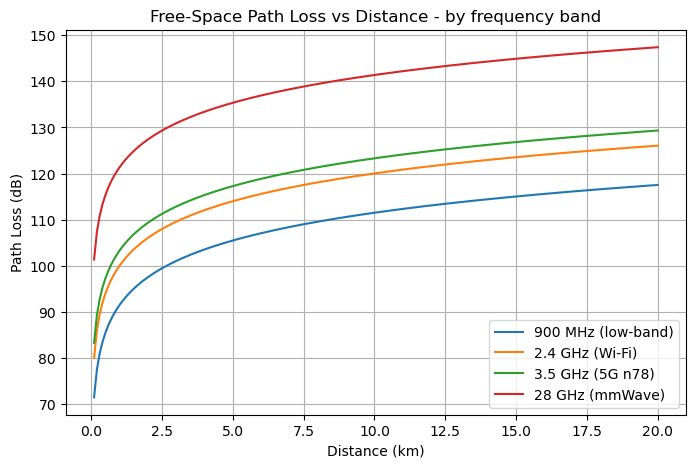

Path loss at d = 1 km:
  900 MHz (low-band)  :   91.5 dB
  2.4 GHz (Wi-Fi)     :  100.0 dB
  3.5 GHz (5G n78)    :  103.3 dB
  28 GHz (mmWave)     :  121.4 dB


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def fspl_db(d_km, f_mhz):
    return 20*np.log10(d_km) + 20*np.log10(f_mhz) + 32.44

distances = np.linspace(0.1, 20, 200)  # km
bands = {"900 MHz (low-band)": 900, "2.4 GHz (Wi-Fi)": 2400,
         "3.5 GHz (5G n78)": 3500, "28 GHz (mmWave)": 28000}

plt.figure(figsize=(8,5))
for label, f in bands.items():
    plt.plot(distances, fspl_db(distances, f), label=label)
plt.xlabel("Distance (km)")
plt.ylabel("Path Loss (dB)")
plt.title("Free-Space Path Loss vs Distance - by frequency band")
plt.grid(True)
plt.legend()
plt.show()

print("Path loss at d = 1 km:")
for label, f in bands.items():
    print(f"  {label:20s}: {fspl_db(1.0, f):6.1f} dB")

All four curves have the same shape, but the higher bands sit higher. At 1 km the 28 GHz signal loses about 30 dB more than 900 MHz, which is roughly one-thousandth of the power. This is why low-band is used for wide coverage while mmWave is limited to short range and deployed as many small cells.

## Summary

The plots show the two rules of free-space path loss: loss grows with distance and with frequency. At 2.4 GHz it reaches about 100 dB at 1 km, and at a fixed distance the 28 GHz mmWave band loses about 30 dB more than 900 MHz. This is the physical reason 5G uses higher frequencies for capacity but has to pack them into small, short-range cells — the same small-cell, edge-heavy design discussed in the companion Assignment 2.

Reference: International Telecommunication Union. (2024). *Recommendation ITU-R P.525-5: Calculation of free-space attenuation.* https://www.itu.int/rec/R-REC-P.525